Original shape: (200, 4)


,fruit_type,color,size,weight
0,grape,Yellow,Tiny,8.303385
1,apple,Pink,Largee,80.976370
2,banana,Pale Yellow,Large,74.615192
3,grape,Red,Tiny,6.924070
4,banana,Creamy White,Largee,82.002542


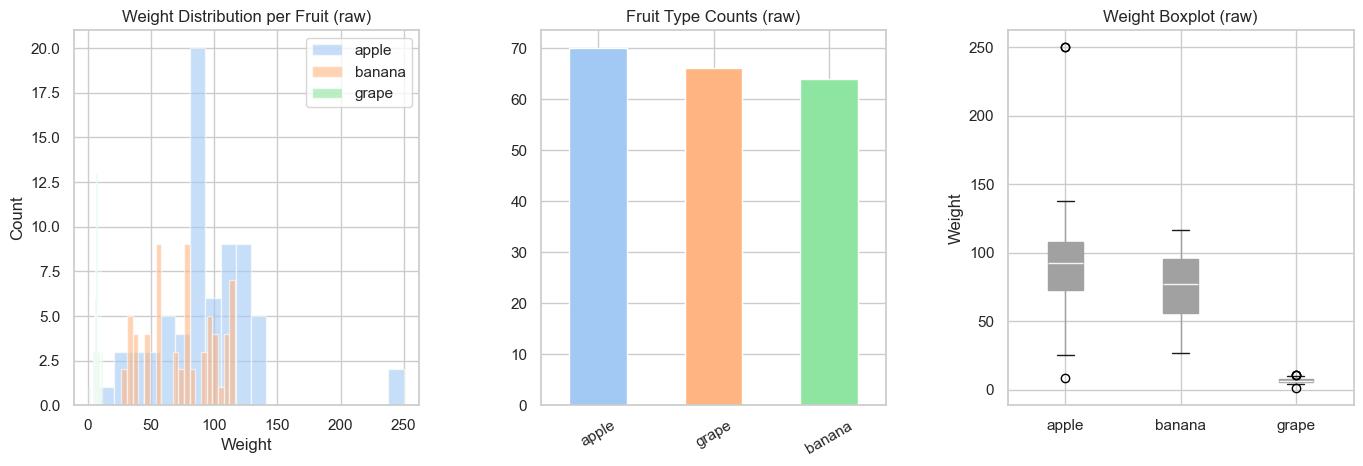


[Step 1] Dropped 0 rows with missing values. Remaining: 200

[Step 2] Lowercased and stripped whitespace.

[Step 3] Colors after digit removal: ['black', 'creamy white', 'green', 'pale yellow', 'pink', 'purple', 'red', 'yellow']
         Sizes  after digit removal: ['large', 'largee', 'medium', 'small', 'tiny']

[Step 4] 'size' — corrected: {'largee'}

[Step 4] Final sizes:  ['large', 'medium', 'small', 'tiny']
         Final colors: ['black', 'creamy white', 'green', 'pale yellow', 'pink', 'purple', 'red', 'yellow']

[Step 5] Removed 7 weight outliers. Remaining: 193
            count   mean    std    min    25%    50%     75%     max
fruit_type                                                          
apple        67.0  90.33  27.13  25.04  72.66  92.58  108.03  137.93
banana       64.0  74.91  27.73  26.52  55.75  77.12   95.45  116.38
grape        62.0   6.79   1.61   4.31   5.82   6.46    7.60    9.91

=== Preprocessing complete ===
Final shape: (193, 4)
label      object
color  

,label,color,size,weight
0,grape,yellow,tiny,8.303385
1,apple,pink,large,80.976370
2,banana,pale yellow,large,74.615192
3,grape,red,tiny,6.924070
4,banana,creamy white,large,82.002542
5,banana,green,large,89.719116
6,apple,green,large,72.036243
7,grape,green,small,5.371310
8,apple,pink,large,87.272178
9,grape,red,small,7.409021


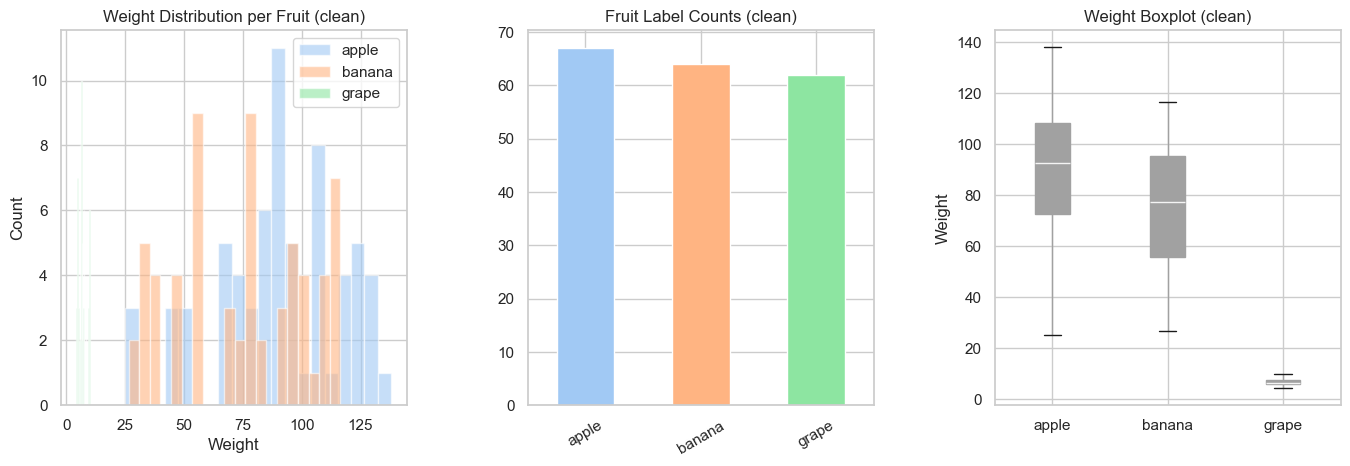

In [7]:

# CELL 1 — Data Preprocessing + Visualization

import pandas as pd
import numpy as np
import re
from difflib import get_close_matches
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style="whitegrid", palette="pastel")

#  Load 
df = pd.read_excel("fruit_data.xlsx", index_col=0)
print(f"Original shape: {df.shape}")
display(df.head())


# VISUALISATION — BEFORE PREPROCESSING

fig = plt.figure(figsize=(16, 5))
fig.suptitle("Data Overview — BEFORE Preprocessing", fontsize=16, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# 1) Weight distribution per fruit (raw — outliers visible)
ax1 = fig.add_subplot(gs[0, 0])
for fruit, grp in df.groupby("fruit_type"):
    ax1.hist(grp["weight"], bins=20, alpha=0.6, label=fruit)
ax1.set_title("Weight Distribution per Fruit (raw)")
ax1.set_xlabel("Weight")
ax1.set_ylabel("Count")
ax1.legend()

# 2) Fruit type counts
ax2 = fig.add_subplot(gs[0, 1])
df["fruit_type"].value_counts().plot(kind="bar", ax=ax2, color=sns.color_palette("pastel"))
ax2.set_title("Fruit Type Counts (raw)")
ax2.set_xlabel("")
ax2.tick_params(axis="x", rotation=30)

# 3) Weight boxplot per fruit (raw — outliers as dots)
ax3 = fig.add_subplot(gs[0, 2])
df.boxplot(column="weight", by="fruit_type", ax=ax3, patch_artist=True)
ax3.set_title("Weight Boxplot (raw)")
ax3.set_xlabel("")
ax3.set_ylabel("Weight")
plt.suptitle("")

plt.show()


# PREPROCESSING STEPS


#  Step 1: Remove rows with missing values 
rows_before = len(df)
df.dropna(inplace=True)
print(f"\n[Step 1] Dropped {rows_before - len(df)} rows with missing values. "
      f"Remaining: {len(df)}")

# Step 2: Lowercase & strip whitespace 
for col in ["fruit_type", "color", "size"]:
    df[col] = df[col].str.strip().str.lower()

print("\n[Step 2] Lowercased and stripped whitespace.")

# Step 3: Remove stray digits from text columns 
for col in ["color", "size"]:
    df[col] = df[col].apply(lambda x: re.sub(r"\d+", "", str(x)).strip())

print(f"\n[Step 3] Colors after digit removal: {sorted(df['color'].unique())}")
print(f"         Sizes  after digit removal: {sorted(df['size'].unique())}")

# Step 4: Fuzzy-match typos to canonical values 
VALID_VALUES = {
    "fruit_type": ["apple", "banana", "grape"],
    "color":      ["black", "creamy white", "green", "pale yellow",
                   "pink", "purple", "red", "yellow"],
    "size":       ["large", "medium", "small", "tiny"],
}

def fuzzy_fix(value, valid_list, cutoff=0.75):
    """Return the closest valid string, or the original if no match found."""
    matches = get_close_matches(value, valid_list, n=1, cutoff=cutoff)
    return matches[0] if matches else value

for col, valid_list in VALID_VALUES.items():
    original_unique = set(df[col].unique())
    df[col] = df[col].apply(lambda x: fuzzy_fix(x, valid_list))
    fixed = original_unique - set(df[col].unique())
    if fixed:
        print(f"\n[Step 4] '{col}' — corrected: {fixed}")

print(f"\n[Step 4] Final sizes:  {sorted(df['size'].unique())}")
print(f"         Final colors: {sorted(df['color'].unique())}")

# Step 5: Remove weight outliers per fruit (IQR method) 
rows_before = len(df)

Q1  = df.groupby("fruit_type")["weight"].transform("quantile", 0.25)
Q3  = df.groupby("fruit_type")["weight"].transform("quantile", 0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = (df["weight"] >= lower_bound) & (df["weight"] <= upper_bound)
df   = df[mask].copy()

print(f"\n[Step 5] Removed {rows_before - len(df)} weight outliers. "
      f"Remaining: {len(df)}")
print(df.groupby("fruit_type")["weight"].describe().round(2))

# Step 6: Ensure textual columns are plain strings 
for col in ["fruit_type", "color", "size"]:
    df[col] = df[col].astype(str)

# Rename target column to 'label' as required
df.rename(columns={"fruit_type": "label"}, inplace=True)

# Step 7: Reset index 
df.reset_index(drop=True, inplace=True)

# Summary 
print("\n=== Preprocessing complete ===")
print(f"Final shape: {df.shape}")
print(df.dtypes)
display(df.head(10))


# VISUALISATION — AFTER PREPROCESSING

fig = plt.figure(figsize=(16, 5))
fig.suptitle("Data Overview — AFTER Preprocessing", fontsize=16, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# 1) Weight distribution per fruit (clean)
ax1 = fig.add_subplot(gs[0, 0])
for fruit, grp in df.groupby("label"):
    ax1.hist(grp["weight"], bins=20, alpha=0.6, label=fruit)
ax1.set_title("Weight Distribution per Fruit (clean)")
ax1.set_xlabel("Weight")
ax1.set_ylabel("Count")
ax1.legend()

# 2) Label counts
ax2 = fig.add_subplot(gs[0, 1])
df["label"].value_counts().plot(kind="bar", ax=ax2, color=sns.color_palette("pastel"))
ax2.set_title("Fruit Label Counts (clean)")
ax2.set_xlabel("")
ax2.tick_params(axis="x", rotation=30)

# 3) Weight boxplot per fruit (clean — no outlier dots)
ax3 = fig.add_subplot(gs[0, 2])
df.boxplot(column="weight", by="label", ax=ax3, patch_artist=True)
ax3.set_title("Weight Boxplot (clean)")
ax3.set_xlabel("")
ax3.set_ylabel("Weight")
plt.suptitle("")

plt.show()

Best hyperparameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV F1 (validation) : 0.8658

========== Decision Tree — K-Fold CV Results (full dataset) ==========
  Train Accuracy  : 0.9275 ± 0.0049
  Test  Accuracy  : 0.8548 ± 0.0271
  Test  F1 (weighted): 0.8528 ± 0.0285
  Test  F1 (macro)   : 0.8549 ± 0.0280
  Overfit gap     : 0.0727  ✓ Healthy

========== Decision Tree — Hold-Out Test Set ==========
  Train Accuracy : 0.9333
  Test  Accuracy : 0.8621
  F1  (weighted) : 0.8621
  F1  (macro)    : 0.8632
  ROC-AUC (OvR)  : 0.9555

--- Classification Report ---
              precision    recall  f1-score   support

       apple       0.80      0.80      0.80        20
      banana       0.79      0.79      0.79        19
       grape       1.00      1.00      1.00        19

    accuracy                           0.86        58
   macro avg       0.86      0.86      0.86        58
weighted avg       0.86      0.86      0.86        58

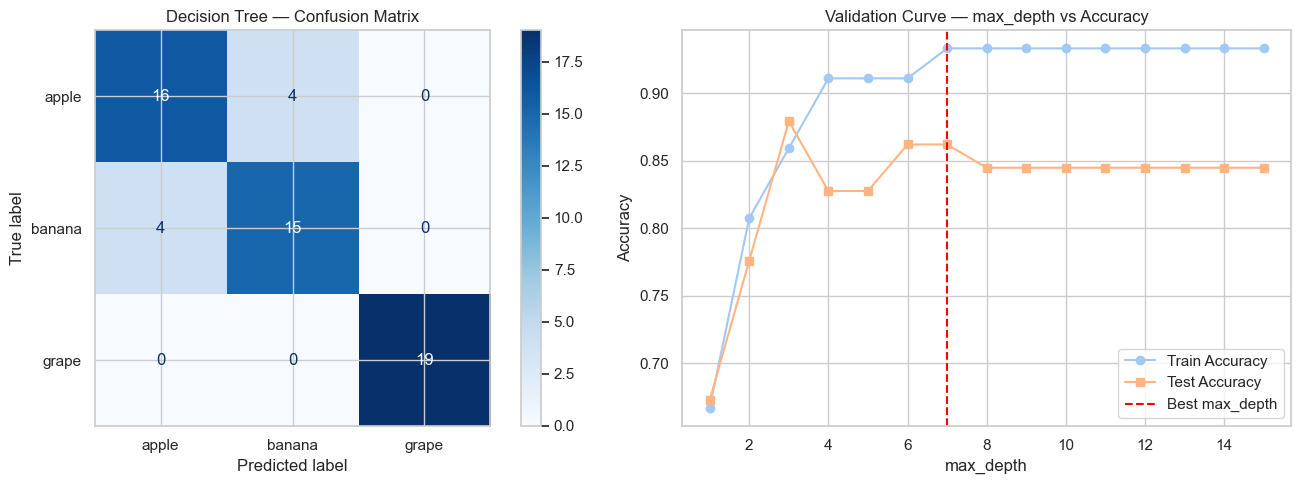

In [45]:

# CELL 2 — Decision Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np

# Feature encoding 
df_model = df.copy()

le_color = LabelEncoder()
le_size  = LabelEncoder()

df_model["color_enc"] = le_color.fit_transform(df_model["color"])
df_model["size_enc"]  = le_size.fit_transform(df_model["size"])

FEATURES = ["color_enc", "size_enc", "weight"]
TARGET   = "label"

X = df_model[FEATURES]
y = df_model[TARGET]

# Train / test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

#  K-Fold strategy (Stratified keeps class ratios per fold) 
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#  Hyperparameter tuning via GridSearchCV + KFold 
param_grid = {
    "max_depth":         [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "criterion":         ["gini", "entropy"],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=kfold,                  # uses the same KFold for tuning
    scoring="f1_weighted",
    n_jobs=-1,
    return_train_score=True    # lets us see train vs val gap per fold
)
grid_search.fit(X_train, y_train)

best_dt = grid_search.best_estimator_
print("Best hyperparameters:", grid_search.best_params_)
print(f"Best CV F1 (validation) : {grid_search.best_score_:.4f}")

#  Cross-validate the best model on the full dataset 
cv_results = cross_validate(
    best_dt, X, y,
    cv=kfold,
    scoring=["accuracy", "f1_weighted", "f1_macro"],
    return_train_score=True
)

print("\n========== Decision Tree — K-Fold CV Results (full dataset) ==========")
print(f"  Train Accuracy  : {cv_results['train_accuracy'].mean():.4f} "
      f"± {cv_results['train_accuracy'].std():.4f}")
print(f"  Test  Accuracy  : {cv_results['test_accuracy'].mean():.4f} "
      f"± {cv_results['test_accuracy'].std():.4f}")
print(f"  Test  F1 (weighted): {cv_results['test_f1_weighted'].mean():.4f} "
      f"± {cv_results['test_f1_weighted'].std():.4f}")
print(f"  Test  F1 (macro)   : {cv_results['test_f1_macro'].mean():.4f} "
      f"± {cv_results['test_f1_macro'].std():.4f}")
gap = cv_results['train_accuracy'].mean() - cv_results['test_accuracy'].mean()
print(f"  Overfit gap     : {gap:.4f}  "
      f"{'⚠ Possible overfit' if gap > 0.1 else '✓ Healthy'}")

#  Final evaluation on held-out test set 
y_train_pred = best_dt.predict(X_train)
y_test_pred  = best_dt.predict(X_test)
y_test_proba = best_dt.predict_proba(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)

print("\n========== Decision Tree — Hold-Out Test Set ==========")
print(f"  Train Accuracy : {train_acc:.4f}")
print(f"  Test  Accuracy : {test_acc:.4f}")
print(f"  F1  (weighted) : {f1_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"  F1  (macro)    : {f1_score(y_test, y_test_pred, average='macro'):.4f}")
print(f"  ROC-AUC (OvR)  : {roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='weighted'):.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_test_pred))

# Plots 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=best_dt.classes_,
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Decision Tree — Confusion Matrix")

# Validation curve: train vs test accuracy across max_depth
depths       = range(1, 16)
train_scores = []
test_scores  = []
for d in depths:
    dt = DecisionTreeClassifier(
        max_depth=d,
        min_samples_split=grid_search.best_params_["min_samples_split"],
        min_samples_leaf=grid_search.best_params_["min_samples_leaf"],
        criterion=grid_search.best_params_["criterion"],
        random_state=42
    )
    dt.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, dt.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  dt.predict(X_test)))

axes[1].plot(depths, train_scores, marker="o", label="Train Accuracy")
axes[1].plot(depths, test_scores,  marker="s", label="Test Accuracy")
axes[1].axvline(grid_search.best_params_["max_depth"] or 15,
                color="red", linestyle="--", label="Best max_depth")
axes[1].set_title("Validation Curve — max_depth vs Accuracy")
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

Best hyperparameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 (validation) : 0.8823

========== Random Forest — K-Fold CV Results (full dataset) ==========
  Train Accuracy  : 0.9430 ± 0.0074
  Test  Accuracy  : 0.8394 ± 0.0096
  Test  F1 (weighted): 0.8380 ± 0.0095
  Test  F1 (macro)   : 0.8404 ± 0.0074
  Overfit gap     : 0.1036  ⚠ Possible overfit

========== Random Forest — Hold-Out Test Set ==========
  Train Accuracy : 0.9481
  Test  Accuracy : 0.8205
  F1  (weighted) : 0.8205
  F1  (macro)    : 0.8272
  ROC-AUC (OvR)  : 0.9378

--- Classification Report ---
              precision    recall  f1-score   support

       apple       0.77      0.71      0.74        14
      banana       0.71      0.77      0.74        13
       grape       1.00      1.00      1.00        12

    accuracy                           0.82        39
   macro avg       0.83      0.83      0.83        39
weighted avg       0.8

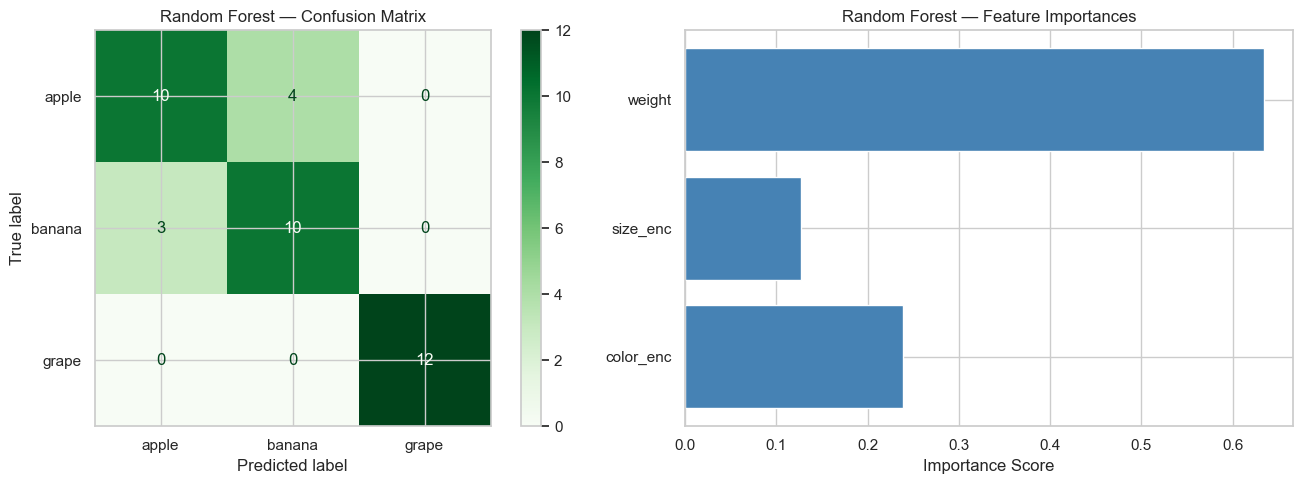

In [47]:

# CELL 3 — Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             roc_auc_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np

#  Train / test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#  K-Fold strategy 
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#  Hyperparameter tuning via GridSearchCV + KFold 
param_grid = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2"],
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_grid,
    cv=kfold,
    scoring="f1_weighted",
    n_jobs=-1,
    return_train_score=True
)
grid_search_rf.fit(X_train, y_train)

best_rf = grid_search_rf.best_estimator_
print("Best hyperparameters:", grid_search_rf.best_params_)
print(f"Best CV F1 (validation) : {grid_search_rf.best_score_:.4f}")

#  Cross-validate the best model on the full dataset 
cv_results = cross_validate(
    best_rf, X, y,
    cv=kfold,
    scoring=["accuracy", "f1_weighted", "f1_macro"],
    return_train_score=True
)

print("\n========== Random Forest — K-Fold CV Results (full dataset) ==========")
print(f"  Train Accuracy  : {cv_results['train_accuracy'].mean():.4f} "
      f"± {cv_results['train_accuracy'].std():.4f}")
print(f"  Test  Accuracy  : {cv_results['test_accuracy'].mean():.4f} "
      f"± {cv_results['test_accuracy'].std():.4f}")
print(f"  Test  F1 (weighted): {cv_results['test_f1_weighted'].mean():.4f} "
      f"± {cv_results['test_f1_weighted'].std():.4f}")
print(f"  Test  F1 (macro)   : {cv_results['test_f1_macro'].mean():.4f} "
      f"± {cv_results['test_f1_macro'].std():.4f}")
gap = cv_results['train_accuracy'].mean() - cv_results['test_accuracy'].mean()
print(f"  Overfit gap     : {gap:.4f}  "
      f"{'⚠ Possible overfit' if gap > 0.1 else '✓ Healthy'}")

#  Final evaluation on held-out test set 
y_train_pred = best_rf.predict(X_train)
y_test_pred  = best_rf.predict(X_test)
y_test_proba = best_rf.predict_proba(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)

print("\n========== Random Forest — Hold-Out Test Set ==========")
print(f"  Train Accuracy : {train_acc:.4f}")
print(f"  Test  Accuracy : {test_acc:.4f}")
print(f"  F1  (weighted) : {f1_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"  F1  (macro)    : {f1_score(y_test, y_test_pred, average='macro'):.4f}")
print(f"  ROC-AUC (OvR)  : {roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='weighted'):.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_test_pred))

# Plots 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=best_rf.classes_,
    cmap="Greens", ax=axes[0]
)
axes[0].set_title("Random Forest — Confusion Matrix")

importances = best_rf.feature_importances_
axes[1].barh(FEATURES, importances, color="steelblue")
axes[1].set_title("Random Forest — Feature Importances")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in versio

Best hyperparameters: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV F1 (validation) : 0.7359

========== Logistic Regression — K-Fold CV Results (full dataset) ==========
  Train Accuracy  : 0.7306 ± 0.0194
  Test  Accuracy  : 0.7198 ± 0.0965
  Test  F1 (weighted): 0.7088 ± 0.1007
  Test  F1 (macro)   : 0.7134 ± 0.0967
  Overfit gap     : 0.0107  ✓ Healthy

========== Logistic Regression — Hold-Out Test Set ==========
  Train Accuracy : 0.7532
  Test  Accuracy : 0.6410
  F1  (weighted) : 0.6124
  F1  (macro)    : 0.6171
  ROC-AUC (OvR)  : 0.8193

--- Classification Report ---
              precision    recall  f1-score   support

       apple       0.64      0.64      0.64        14
      banana       0.50      0.31      0.38        13
       grape       0.71      1.00      0.83        12

    accuracy                           0.64        39
   macro avg       0.62      0.65      0.62        39
weighted avg       0.61      0.64      0.61        39



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in versio

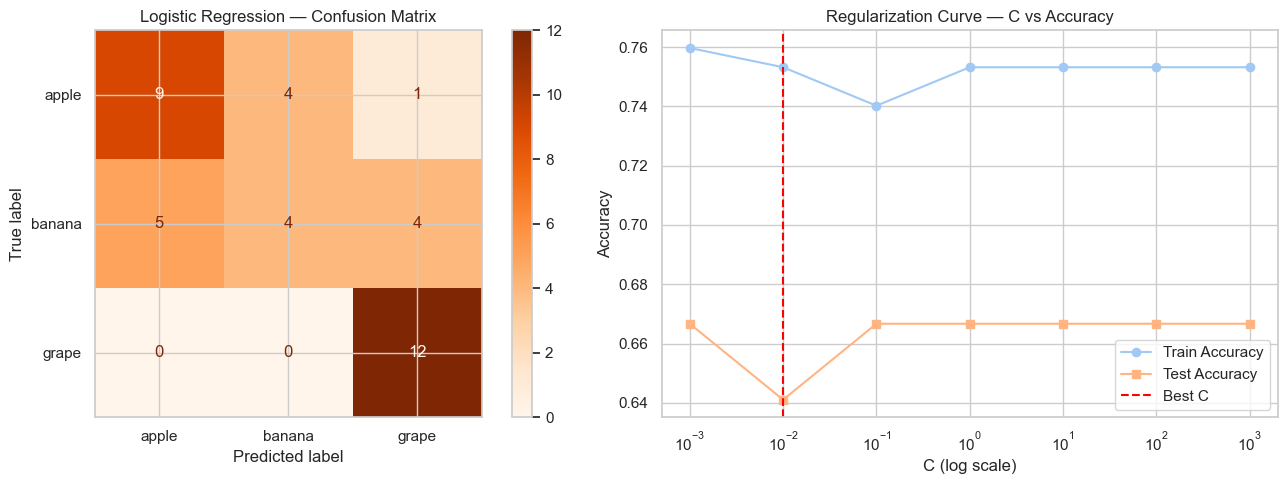

In [49]:

# CELL 4 — Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             roc_auc_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np

# Train / test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# K-Fold strategy 
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline: scaling + model 
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(
        multi_class="multinomial",
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

param_grid = {
    "model__C":       [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],
    "model__solver":  ["lbfgs", "saga"],
}

grid_search_lr = GridSearchCV(
    pipeline,
    param_grid,
    cv=kfold,
    scoring="f1_weighted",
    n_jobs=-1,
    return_train_score=True
)
grid_search_lr.fit(X_train, y_train)

best_lr = grid_search_lr.best_estimator_
print("Best hyperparameters:", grid_search_lr.best_params_)
print(f"Best CV F1 (validation) : {grid_search_lr.best_score_:.4f}")

#  Cross-validate the best model on the full dataset 
cv_results = cross_validate(
    best_lr, X, y,
    cv=kfold,
    scoring=["accuracy", "f1_weighted", "f1_macro"],
    return_train_score=True
)

print("\n========== Logistic Regression — K-Fold CV Results (full dataset) ==========")
print(f"  Train Accuracy  : {cv_results['train_accuracy'].mean():.4f} "
      f"± {cv_results['train_accuracy'].std():.4f}")
print(f"  Test  Accuracy  : {cv_results['test_accuracy'].mean():.4f} "
      f"± {cv_results['test_accuracy'].std():.4f}")
print(f"  Test  F1 (weighted): {cv_results['test_f1_weighted'].mean():.4f} "
      f"± {cv_results['test_f1_weighted'].std():.4f}")
print(f"  Test  F1 (macro)   : {cv_results['test_f1_macro'].mean():.4f} "
      f"± {cv_results['test_f1_macro'].std():.4f}")
gap = cv_results['train_accuracy'].mean() - cv_results['test_accuracy'].mean()
print(f"  Overfit gap     : {gap:.4f}  "
      f"{'⚠ Possible overfit' if gap > 0.1 else '✓ Healthy'}")

#  Final evaluation on held-out test set 
y_train_pred = best_lr.predict(X_train)
y_test_pred  = best_lr.predict(X_test)
y_test_proba = best_lr.predict_proba(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)

print("\n========== Logistic Regression — Hold-Out Test Set ==========")
print(f"  Train Accuracy : {train_acc:.4f}")
print(f"  Test  Accuracy : {test_acc:.4f}")
print(f"  F1  (weighted) : {f1_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"  F1  (macro)    : {f1_score(y_test, y_test_pred, average='macro'):.4f}")
print(f"  ROC-AUC (OvR)  : {roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='weighted'):.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_test_pred))

# Plots 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=best_lr.classes_,
    cmap="Oranges", ax=axes[0]
)
axes[0].set_title("Logistic Regression — Confusion Matrix")

C_values     = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_scores = []
test_scores  = []
best_solver  = grid_search_lr.best_params_["model__solver"]

for c in C_values:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LogisticRegression(
            C=c, solver=best_solver,
            multi_class="multinomial",
            class_weight="balanced",
            random_state=42, max_iter=1000
        ))
    ])
    pipe.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, pipe.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  pipe.predict(X_test)))

axes[1].semilogx(C_values, train_scores, marker="o", label="Train Accuracy")
axes[1].semilogx(C_values, test_scores,  marker="s", label="Test Accuracy")
axes[1].axvline(grid_search_lr.best_params_["model__C"],
                color="red", linestyle="--", label="Best C")
axes[1].set_title("Regularization Curve — C vs Accuracy")
axes[1].set_xlabel("C (log scale)")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

Evaluating test_size=0.10 ... 

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


done.
Evaluating test_size=0.15 ... 

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


done.
Evaluating test_size=0.20 ... 

...

C:\ProgramData\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


done.

========== Test Accuracy by Test Size ==========


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,train_size,Decision Tree,Random Forest,Logistic Regression
test_size,,,,
0.10,0.90,0.8500,0.7500,0.7000
0.15,0.85,0.7931,0.8276,0.7241
0.20,0.80,0.8462,0.8205,0.6667
0.25,0.75,0.8367,0.7959,0.6531
0.30,0.70,0.8621,0.8276,0.6724
0.35,0.65,0.7941,0.7941,0.6471
0.40,0.60,0.8590,0.8077,0.6795



========== Best Test Size per Model ==========
  Decision Tree          → test_size=0.30  |  accuracy=0.8621
  Random Forest          → test_size=0.15  |  accuracy=0.8276
  Logistic Regression    → test_size=0.15  |  accuracy=0.7241

  Best overall split     → test_size=0.30  |  mean accuracy=0.7874


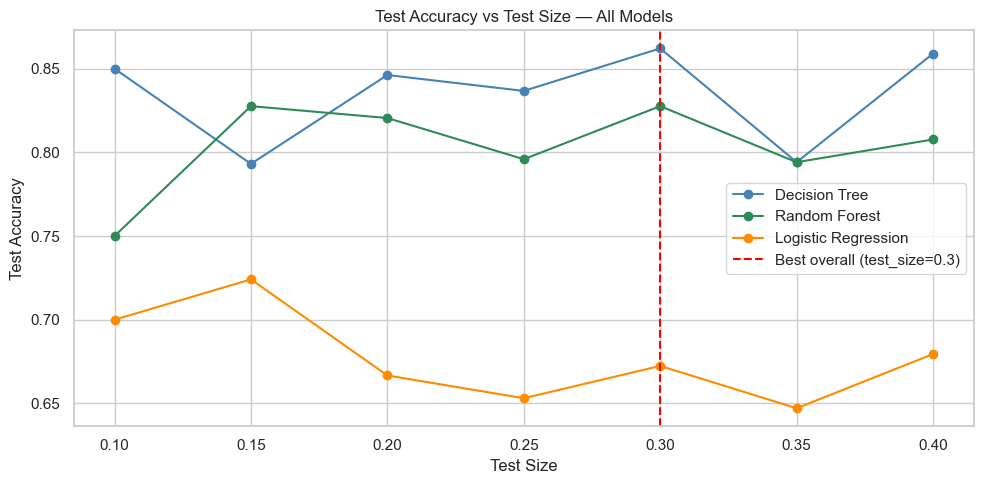

In [37]:

# CELL 5 — Best Test Size Selection (with per-split tuning)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

TEST_SIZES = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]

#  Param grids (same as Cells 2-4) 
dt_param_grid = {
    "max_depth":         [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "criterion":         ["gini", "entropy"],
}

rf_param_grid = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2"],
}

lr_param_grid = {
    "model__C":       [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],
    "model__solver":  ["lbfgs", "saga"],
}

results = []

for test_size in TEST_SIZES:
    print(f"Evaluating test_size={test_size:.2f} ...", end=" ")

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    #  Decision Tree 
    dt_gs = GridSearchCV(
        DecisionTreeClassifier(random_state=42),
        dt_param_grid, cv=5, scoring="f1_weighted", n_jobs=-1
    )
    dt_gs.fit(X_tr, y_tr)
    dt_acc = accuracy_score(y_te, dt_gs.best_estimator_.predict(X_te))

    #  Random Forest 
    rf_gs = GridSearchCV(
        RandomForestClassifier(random_state=42, class_weight="balanced"),
        rf_param_grid, cv=5, scoring="f1_weighted", n_jobs=-1
    )
    rf_gs.fit(X_tr, y_tr)
    rf_acc = accuracy_score(y_te, rf_gs.best_estimator_.predict(X_te))

    #  Logistic Regression 
    lr_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LogisticRegression(
            multi_class="multinomial",
            class_weight="balanced",
            random_state=42,
            max_iter=1000
        ))
    ])
    lr_gs = GridSearchCV(
        lr_pipeline, lr_param_grid, cv=5, scoring="f1_weighted", n_jobs=-1
    )
    lr_gs.fit(X_tr, y_tr)
    lr_acc = accuracy_score(y_te, lr_gs.best_estimator_.predict(X_te))

    results.append({
        "test_size":           test_size,
        "train_size":          round(1 - test_size, 2),
        "Decision Tree":       round(dt_acc, 4),
        "Random Forest":       round(rf_acc, 4),
        "Logistic Regression": round(lr_acc, 4),
    })
    print("done.")

#  Results table 
results_df = pd.DataFrame(results).set_index("test_size")
print("\n========== Test Accuracy by Test Size ==========")
display(results_df)

# Best split per model 
print("\n========== Best Test Size per Model ==========")
for model in ["Decision Tree", "Random Forest", "Logistic Regression"]:
    best_idx = results_df[model].idxmax()
    best_acc = results_df[model].max()
    print(f"  {model:<22} → test_size={best_idx:.2f}  |  accuracy={best_acc:.4f}")

#  Overall best split (highest mean accuracy across models) 
results_df["mean_accuracy"] = results_df[
    ["Decision Tree", "Random Forest", "Logistic Regression"]
].mean(axis=1)

best_overall_size = results_df["mean_accuracy"].idxmax()
best_overall_acc  = results_df["mean_accuracy"].max()
print(f"\n  {'Best overall split':<22} → test_size={best_overall_size:.2f}  "
      f"|  mean accuracy={best_overall_acc:.4f}")

# Plot 
fig, ax = plt.subplots(figsize=(10, 5))

for model, color in zip(
    ["Decision Tree", "Random Forest", "Logistic Regression"],
    ["steelblue", "seagreen", "darkorange"]
):
    ax.plot(TEST_SIZES, results_df[model], marker="o", label=model, color=color)

ax.axvline(best_overall_size, color="red", linestyle="--",
           label=f"Best overall (test_size={best_overall_size})")
ax.set_title("Test Accuracy vs Test Size — All Models")
ax.set_xlabel("Test Size")
ax.set_ylabel("Test Accuracy")
ax.set_xticks(TEST_SIZES)
ax.legend()
plt.tight_layout()
plt.show()